## Imports

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, make_scorer, f1_score, average_precision_score
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier

r_state = 42

# 1) Dataförståelse & EDA (kort men relevant)

## Load Data

In [2]:
df = pd.read_csv("Project/Data/historical_data.csv")

## Check Data
* Lower **account_age_days**, **message_length** and **num_prev_listings** might be suspicious
* Higher **urgency_words** might be suspicious

In [3]:
df.head()

,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
0,0,8,ad_post,other,urban,android,38.4,2,1,1,594.16,3,91,0,1,0,2.3,0
1,1,4,ad_post,fashion,urban,android,20.0,1,0,1,134.47,2,150,0,0,0,13.6,0
2,2,4,ad_post,other,metro,ios,46.7,3,1,1,198.52,3,72,0,0,0,4.2,0
3,3,3,ad_post,furniture,metro,android,44.3,3,1,2,141.20,3,0,0,0,0,19.8,0
4,4,1,ad_post,electronics,metro,web,211.2,5,0,0,81.39,3,9,0,0,1,23.3,0


In [4]:
df.describe()

,id,day,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,11182.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,11410.000000,12000.000000
mean,5999.50000,7.482667,99.632567,3.027750,0.151500,0.710167,207.348603,2.870417,111.154417,0.072833,0.099083,0.181167,22.160438,0.102000
std,3464.24595,4.032520,112.903541,1.766467,0.386083,0.719171,196.226023,1.766886,66.396885,0.259874,0.298786,0.385172,28.834047,0.302661
min,0.00000,1.000000,2.200000,0.000000,0.000000,0.000000,7.670000,0.000000,0.000000,0.000000,0.000000,0.000000,0.300000,0.000000
25%,2999.75000,4.000000,36.300000,2.000000,0.000000,0.000000,86.195000,2.000000,63.000000,0.000000,0.000000,0.000000,6.700000,0.000000
50%,5999.50000,7.000000,66.600000,3.000000,0.000000,1.000000,149.225000,3.000000,108.000000,0.000000,0.000000,0.000000,13.400000,0.000000
75%,8999.25000,11.000000,120.700000,4.000000,0.000000,1.000000,256.795000,4.000000,155.000000,0.000000,0.000000,0.000000,26.600000,0.000000
max,11999.00000,14.000000,2741.700000,12.000000,3.000000,2.000000,2743.080000,10.000000,416.000000,1.000000,1.000000,1.000000,579.800000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          12000 non-null  int64  
 1   day                         12000 non-null  int64  
 2   event_type                  12000 non-null  object 
 3   category                    12000 non-null  object 
 4   region                      11660 non-null  object 
 5   device                      12000 non-null  object 
 6   account_age_days            12000 non-null  float64
 7   num_prev_listings           12000 non-null  int64  
 8   prev_reports_30d            12000 non-null  int64  
 9   verification_level          12000 non-null  int64  
 10  price                       11182 non-null  float64
 11  num_images                  12000 non-null  int64  
 12  message_length              12000 non-null  int64  
 13  contains_off_platform       120

In [6]:
df.isna().sum()

id                              0
day                             0
event_type                      0
category                        0
region                        340
device                          0
account_age_days                0
num_prev_listings               0
prev_reports_30d                0
verification_level              0
price                         818
num_images                      0
message_length                  0
contains_off_platform           0
urgency_words                   0
payment_attempt                 0
time_to_first_response_min    590
is_suspicious                   0
dtype: int64

## Missing Data
* 340 region - May be hidden intentionally. **Less important feature**
* 818 price - Hidden or not determined yet. **Important feature**
* 590 time_to_first_response_min - Email not important, trash/spam. **Important feature**

Add flag columns för missing data. 1 for missing, 0 for not missing.

1. NaN regions will be filled with Unknown. It is categorical so can be filled without fear of altering training.
2. NaN prices will be filled with their respective product category median to avoid skewing data and since that the median per category is likely very different.
3. NaN response times will be filled with the maximum response + 1 to indicate it is non-existant.

All these values have a flag to indicate that the values were missing and can be handled appropriately.

In [7]:
clean_df = df.copy()

# 1 means missing, 0 means not missing
clean_df["missing_region"] = np.where(clean_df["region"].isna(), 1, 0)
clean_df["region"] = clean_df["region"].fillna("Unknown") # Filling with unknown to avoid NaN

clean_df["missing_price"] = np.where(clean_df["price"].isna(), 1, 0)
clean_df["price"] = clean_df.groupby("category")["price"].transform( # Fill nan prices with categorical median
    lambda x: x.fillna(x.median())
)

clean_df["missing_response"] = np.where(clean_df["time_to_first_response_min"].isna(), 1, 0)
clean_df["time_to_first_response_min"] = clean_df["time_to_first_response_min"].fillna(clean_df["time_to_first_response_min"].max() + 1)

In [8]:
clean_df.loc[(clean_df["missing_price"] == 1) & (clean_df["missing_region"] == 1) & (clean_df["missing_response"] == 1)]

,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,...,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious,missing_region,missing_price,missing_response
395,395,14,ad_post,other,Unknown,ios,67.2,1,0,1,...,6,83,0,0,0,580.8,0,1,1,1
7826,7826,13,message_send,other,Unknown,ios,189.9,1,0,1,...,4,126,0,0,0,580.8,0,1,1,1


## Graphing
### Histrogram (price)
We can see from the pricing histogram that it is very left-skewed and the maximum price is not even visible. Will make a histogram with the log of price to see distribution better.

2743.08


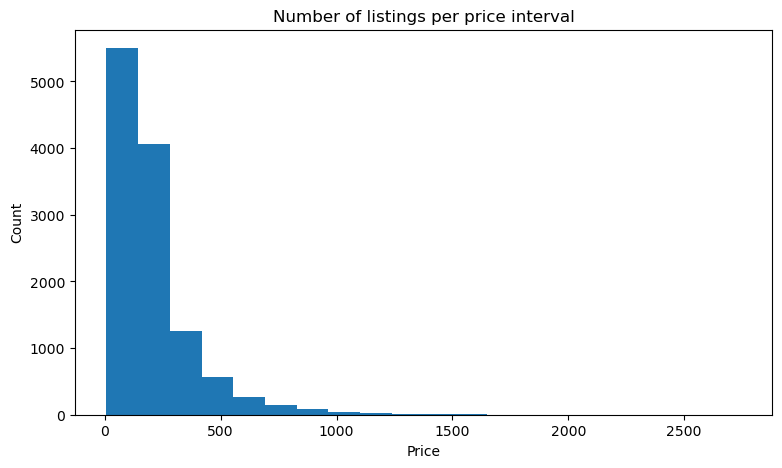

In [9]:
print(clean_df["price"].max())

plt.figure(figsize=(9, 5))
plt.hist(clean_df["price"], bins=20)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Number of listings per price interval")
plt.show()

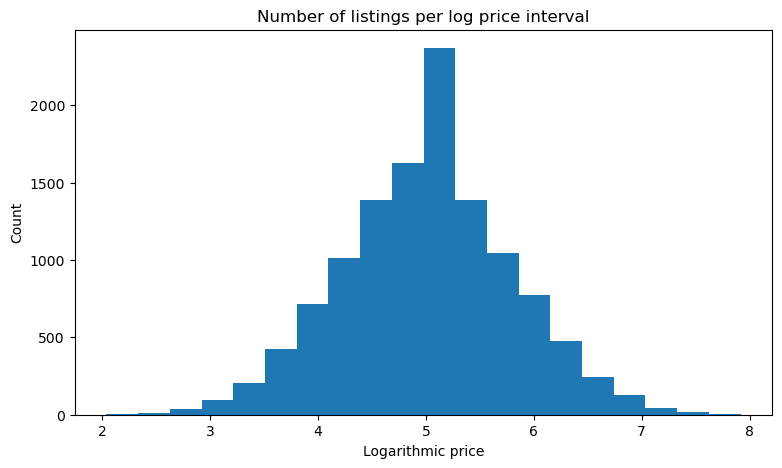

In [10]:
plt.figure(figsize=(9, 5))
plt.hist(np.log(clean_df["price"]), bins=20)
plt.xlabel("Logarithmic price")
plt.ylabel("Count")
plt.title("Number of listings per log price interval")
plt.show()

### Histrogram (account_age_days)

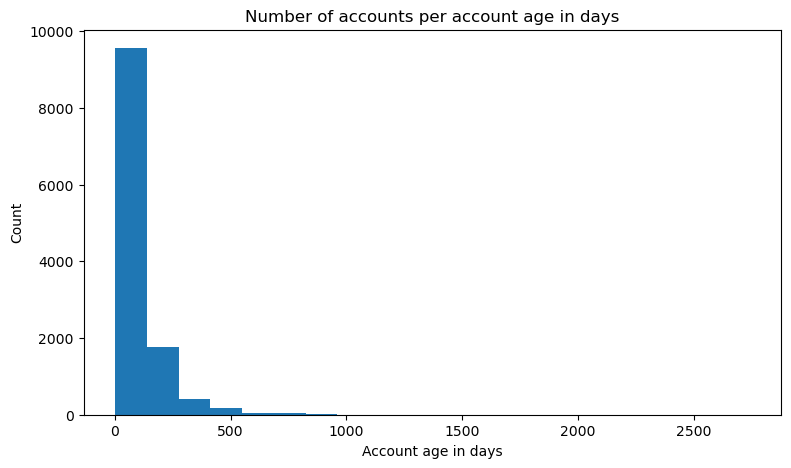

In [11]:
plt.figure(figsize=(9, 5))
plt.hist(clean_df["account_age_days"], bins=20)
plt.xlabel("Account age in days")
plt.ylabel("Count")
plt.title("Number of accounts per account age in days")
plt.show()

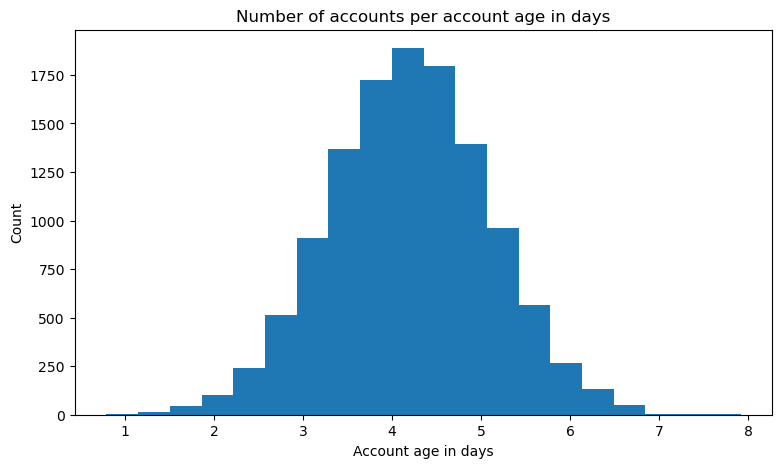

In [12]:
plt.figure(figsize=(9, 5))
plt.hist(np.log(clean_df["account_age_days"]), bins=20)
plt.xlabel("Account age in days")
plt.ylabel("Count")
plt.title("Number of accounts per account age in days")
plt.show()

### Boxplot (is_suspicious vs price)
Boxplot showing outliers in price between suspicious level

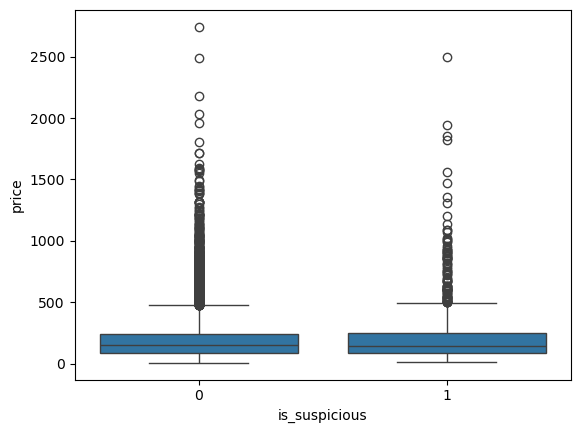

In [13]:
sns.boxplot(x="is_suspicious", y="price", data=clean_df)
plt.show()

### Barplot (missing values vs is_suspicious)
This barplot plots the suspicious rate versus the missing features (region, price and response).


Missing price and missing a response appear to have a higher suspicious rate. Missing region seem to be lower.

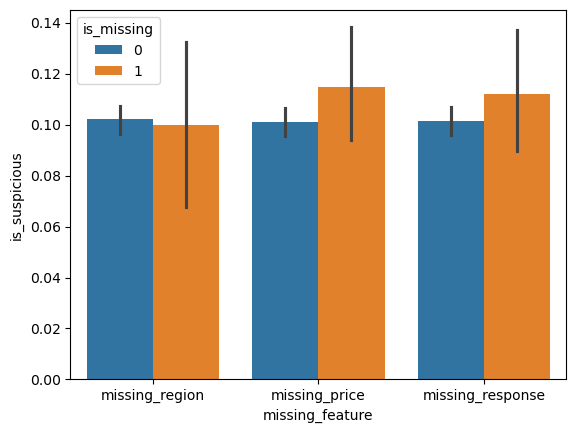

In [14]:
melted = clean_df.melt(
    id_vars="is_suspicious",
    value_vars=["missing_region", "missing_price", "missing_response"],
    var_name="missing_feature",
    value_name="is_missing"
)

sns.barplot(
    x="missing_feature",
    y="is_suspicious",
    hue="is_missing",
    data=melted
)
plt.show()

### Barplot (is_suspicious rate vs urgency_words and contains_off_platform)
These barplots show a correlation between suspiciousness and the amount of urgency words and if the listing is off platform. 

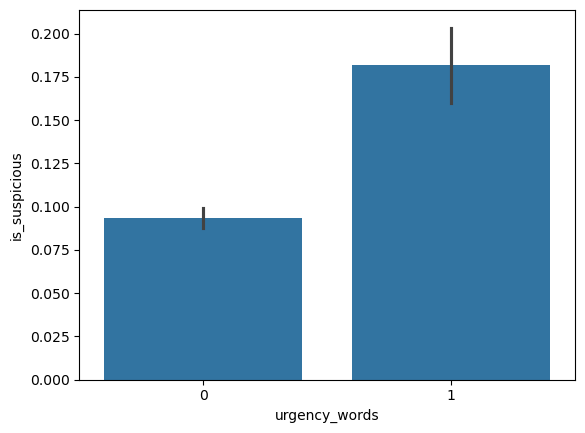

In [15]:
sns.barplot(x="urgency_words", y="is_suspicious", data=clean_df)
plt.show()

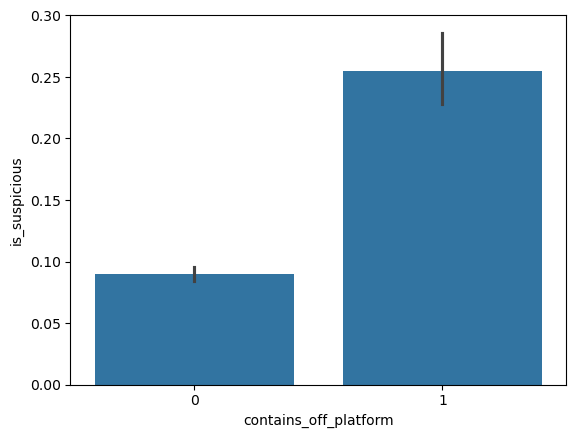

In [16]:
sns.barplot(x="contains_off_platform", y="is_suspicious", data=clean_df)
plt.show()

# 2) Train/test + preprocessing (korrekt workflow)

In [17]:
# Drop the label "is_suspicious" and "id" as it irrelevant as a feature
# Features
x = clean_df.drop(columns=["is_suspicious", "id"], axis=1)
# Label
y = clean_df["is_suspicious"]

# First split: train + test
x_train_full, x_test, y_train_full, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=r_state
)

# Second split: train + validation
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.25,  # 0.25 of 80% = 20%
    stratify=y_train_full,
    random_state=r_state
)

# x_train, x_test, y_train, y_test = train_test_split(
#     x,
#     y,
#     test_size=0.2,
#     stratify=y,
#     random_state=r_state
# )

### Divide numerical and categorical features

In [18]:
num_features = ["day", "account_age_days", "num_prev_listings", "prev_reports_30d",
                "verification_level", "price", "num_images", "message_length",
                "contains_off_platform", "urgency_words", "payment_attempt", "time_to_first_response_min",
                "missing_region", "missing_price", "missing_response"]
cat_features = ["event_type", "category", "region", "device"]

### Create numeric and categorical pipelines

In [19]:
# Using median as it is more stable for skewed values as seen in the distribution plots of price and account_age_days
# Keeping imputer despite having no missing values. Good for safety if new data is available
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Keeping imputer despite having no missing values. Good for safety if new data is available
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Finished preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features)
    ]
)

# 3) Modellering och jämförelse
Models will be compared by PR-AUC score as it is not dependant on thresholds. Comparing by f1-score is misleading as it requires threshold tuning which will be done after a model has been chosen.

In [20]:
# Cross Validation strategy
cv_strat = StratifiedKFold(n_splits=10, shuffle=True, random_state=r_state)

# Used for comparing models
auc_scorer = make_scorer(average_precision_score, response_method="predict_proba")

# Used for tuning models
f1_scorer = make_scorer(f1_score, pos_label=1)

In [21]:
f1_scores = {
    "Model": [],
    "f1 score": []
}

auc_scores = {
    "Model": [],
    "PR-AUC score": []
}

### Dummy baseline

In [22]:
# Model setup
dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(
        strategy="stratified", # stratified, most_frequent
        random_state=r_state
        ))
])

# Stratified k-fold cross validation evaluation
dummy_scores = cross_val_score(dummy_model, x_train, y_train, cv=cv_strat, scoring=auc_scorer)
auc_scores["Model"].append("Dummy")
auc_scores["PR-AUC score"].append(np.mean(dummy_scores))
print("Dummy mean AUC:", np.mean(dummy_scores))

# dummy_cv_scores = cross_val_score(dummy_model, x, y, cv=cv_strat, scoring=f1_scorer)
# f1_scores["Model"].append("Dummy")
# f1_scores["f1 score"].append(np.mean(dummy_cv_scores))
# print("Dummy mean F1:", np.mean(dummy_cv_scores))

Dummy mean AUC: 0.10211936763306625


### Logistic Regression

In [23]:
# Model setup
logistic_regression_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=r_state
        ))
])

# Stratified k-fold cross validation evaluation
logistic_regression_scores = cross_val_score(logistic_regression_model, x_train, y_train, cv=cv_strat, scoring=auc_scorer)
auc_scores["Model"].append("Logistic Regression")
auc_scores["PR-AUC score"].append(np.mean(logistic_regression_scores))
print("Logistic Regression mean AUC:", np.mean(logistic_regression_scores))

# logistic_regression_cv_scores = cross_val_score(logistic_regression_model, x, y, cv=cv_strat, scoring=f1_scorer)
# f1_scores["Model"].append("Logistic Regression")
# f1_scores["f1 score"].append(np.mean(logistic_regression_cv_scores))
# print("Logistic Regression mean F1:", np.mean(logistic_regression_cv_scores))

Logistic Regression mean AUC: 0.30022832527259846


### Random Forest Classifier

In [24]:
# Model setup
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=r_state
        ))
])

# Stratified k-fold cross validation evaluation
rf_scores = cross_val_score(random_forest_model, x_train, y_train, cv=cv_strat, scoring=auc_scorer)
auc_scores["Model"].append("Random Forest Classifier")
auc_scores["PR-AUC score"].append(np.mean(rf_scores))
print("Random Forest mean AUC:", np.mean(rf_scores))

# random_forest_cv_scores = cross_val_score(random_forest_model, x, y, cv=cv_strat, scoring=f1_scorer)
# f1_scores["Model"].append("Random Forest Classifier")
# f1_scores["f1 score"].append(np.mean(random_forest_cv_scores))
# print("Random Forest mean F1:", np.mean(random_forest_cv_scores))

Random Forest mean AUC: 0.2501665500955489


### XGBoost

In [25]:
# Model setup
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=r_state
    ))
])

# Stratified k-fold cross validation evaluation
xgb_scores = cross_val_score(xgb_model, x_train, y_train, cv=cv_strat, scoring=auc_scorer)
auc_scores["Model"].append("XGBoost")
auc_scores["PR-AUC score"].append(np.mean(xgb_scores))
print("XGBoost mean AUC:", np.mean(xgb_scores))

# xgb_cv_scores = cross_val_score(xgb_model, x, y, cv=cv_strat, scoring=f1_scorer)
# f1_scores["Model"].append("XGBoost")
# f1_scores["f1 score"].append(np.mean(xgb_cv_scores))
# print("XGBoost mean F1:", np.mean(xgb_cv_scores))

XGBoost mean AUC: 0.2344731578417003


In [26]:
f1_model_results = pd.DataFrame(f1_scores)
f1_model_results.sort_values(by="f1 score", ascending=False, inplace=True, ignore_index=True)

auc_model_results = pd.DataFrame(auc_scores)
auc_model_results.sort_values(by="PR-AUC score", ascending=False, inplace=True, ignore_index=True)

In [27]:
display(f1_model_results)
display(auc_model_results)

,Model,f1 score


,Model,PR-AUC score
0,Logistic Regression,0.300228
1,Random Forest Classifier,0.250167
2,XGBoost,0.234473
3,Dummy,0.102119


### OLD RESULTS
* Model-------------------------------PR-AUC score
* Logistic Regression-----------0.282134
* Random Forest Classifier--0.260976
* XGBoost---------------------------0.232597
* Dummy----------------------------0.102628

# 4) Välj och optimera EN modell (hyperparameter-tuning)
Will chose and optimize the Logistic Regression model based on the highest PR-AUC score

### Train new model with hyperparameters

In [28]:
# Model setup
new_logistic_regression_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=r_state
        ))
])

param_grid = {
    "classifier__C": [10, 100, 1000],
    "classifier__penalty": ["l2"],
    "classifier__class_weight": [None, "balanced"],
    "classifier__solver": ["lbfgs"],
    "classifier__max_iter": [200, 500, 800, 1000]
}

grid = GridSearchCV(
    estimator=new_logistic_regression_model,
    param_grid=param_grid,
    scoring="f1",
    cv=cv_strat,
    n_jobs=-1
)

grid.fit(x_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['day',
                                                                          'account_age_days',
                                                                          'num_prev_listings',
                                                                          'prev_reports_30d',
                                                                          'verification_level',
                                                                          'price',
                                                                          'num_image...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['event_type',
                                                                          'category',
                                                                          'region',
                                                                          'device'])])),
                                       ('classifier',
                                        LogisticRegression(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [10, 100, 1000],
                         'classifier__class_weight': [None, 'balanced'],
                         'classifier__max_iter': [200, 500, 800, 1000],
                         'classifier__penalty': ['l2'],
                         'classifier__solver': ['lbfgs']},
             scoring='f1')

In [29]:
print(grid.best_params_)
print(grid.best_score_)

{'classifier__C': 100, 'classifier__class_weight': 'balanced', 'classifier__max_iter': 200, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
0.30439365046007205


In [30]:
best_model = grid.best_estimator_
probs = best_model.predict_proba(x_val)[:, 1]

#thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55]
#thresholds = [0.55, 0.56, 0.57, 0.58, 0.59, 0.60, 0.61, 0.62, 0.63, 0.64, 0.65]
thresholds = np.linspace(0.55, 0.65, 100)

best_threshold = 0
best_f1 = 0

for t in thresholds:
    preds = (probs > t).astype(int)
    f1 = f1_score(y_val, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best threshold:", best_threshold)
print("Best validation F1:", best_f1)

Best threshold: 0.6035353535353536
Best validation F1: 0.3509272467902996


In [31]:
# Round best threshold to 2 decimals
best_threshold = np.round(best_threshold, 2)
print(best_threshold)

0.6
